**Sample Entropy (order = 2, tolerance = 0.2)**

In [1]:
# BEN CODE — z-score normalized, correct ROI count for order = 2

!pip install antropy pandas numpy tqdm joblib --quiet

import os
import zipfile
import numpy as np
import pandas as pd
from tqdm import tqdm
from antropy import sample_entropy
from joblib import Parallel, delayed
import multiprocessing

csv_path  = "/content/MINI_label.csv"
zip_path  = "/content/netts_files.zip"

df = pd.read_csv(csv_path)
df.columns = df.columns.str.strip()

extract_folder = "/content/netts_data"
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_folder)

data_folder = "/content/netts_data/Glasser_HCP"
print("Total files:", len(os.listdir(data_folder)))

# BEN FUNCTION — with z-score normalization (critical fix)
def compute_subject_ben(row):
    try:
        usercode = str(int(row["User.code"]))
        filename = f"sub-{usercode.zfill(12)}_000.netts"
        filepath = os.path.join(data_folder, filename)

        if not os.path.exists(filepath):
            return None

        ts = np.loadtxt(filepath)         # shape: (360, n_rois) — n_rois=164 or 155

        if ts.ndim == 1:
            ts = ts.reshape(-1, 1)

        roi_entropy = []

        for col in range(ts.shape[1]):
            signal = ts[:, col]
            signal = signal[~np.isnan(signal)]

            if len(signal) < 10:
                continue

            std = np.std(signal)
            if std < 1e-10:
                continue

            # CRITICAL FIX: z-score normalize before SampleEntropy
            # Without this, r = 0.2 * ~2700 = huge → all subjects get ~same SE
            signal = (signal - np.mean(signal)) / std

            try:
                # order=2, r=0.2*std=0.2 (since std=1 after z-score) — standard params
                e = sample_entropy(signal, order=2, tolerance=0.2)
                if np.isfinite(e):
                    roi_entropy.append(float(e))
            except:
                continue

        if len(roi_entropy) == 0:
            return None

        return [usercode, float(np.mean(roi_entropy))]

    except:
        return None

# PARALLEL PROCESSING
n_jobs = multiprocessing.cpu_count()
print(f"Using {n_jobs} CPU cores")

results = Parallel(n_jobs=n_jobs)(
    delayed(compute_subject_ben)(row)
    for _, row in tqdm(df.iterrows(), total=len(df))
)

results = [r for r in results if r is not None]

res = pd.DataFrame(results, columns=["User.code", "BEN"])

# Quick sanity check — BEN should vary meaningfully across subjects
print(f"\nTotal subjects processed: {len(res)}")
print(f"BEN range   : {res['BEN'].min():.4f} → {res['BEN'].max():.4f}")
print(f"BEN mean    : {res['BEN'].mean():.4f}")
print(f"BEN std     : {res['BEN'].std():.4f}")        # should be > 0.05 if working correctly
print(res.head(10))

res.to_csv("/content/BEN_values_order2.csv", index=False)
print("Saved BEN_values_order2.csv")

Total files: 1024
Using 2 CPU cores


100%|██████████| 8351/8351 [02:17<00:00, 60.68it/s] 



Total subjects processed: 988
BEN range   : 1.1405 → 1.9054
BEN mean    : 1.5008
BEN std     : 0.1092
  User.code       BEN
0  10155078  1.642470
1  10218000  1.527128
2  10225245  1.455978
3  10229783  1.500486
4  10382566  1.443651
5  10387970  1.575219
6  10450441  1.648580
7  10488996  1.660435
8  10574254  1.728657
9  10683468  1.309651
Saved BEN_values_order2.csv


Condition
Healthy      795
Unhealthy    193
Name: count, dtype: int64


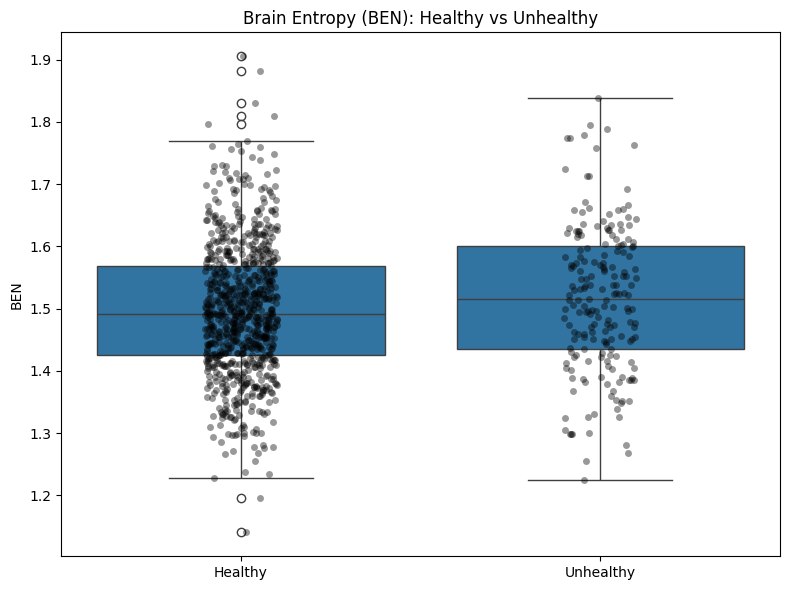

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load files
labels = pd.read_csv("/content/MINI_label.csv")
ben = pd.read_csv("/content/BEN_values_order2.csv")

labels.columns = labels.columns.str.strip()

# Merge
df = pd.merge(labels, ben, on="User.code")

# Healthy vs Unhealthy
df["Condition"] = df.apply(
    lambda row: "Healthy"
    if row["externalizing_spectrum"]==0 and
       row["internalizing_spectrum"]==0 and
       row["mood_psychosis_spectrum"]==0
    else "Unhealthy",
    axis=1
)

print(df["Condition"].value_counts())

# Plot
plt.figure(figsize=(8,6))

sns.boxplot(data=df, x="Condition", y="BEN")

sns.stripplot(data=df, x="Condition", y="BEN",
              color="black", alpha=0.4)

plt.title("Brain Entropy (BEN): Healthy vs Unhealthy")
plt.ylabel("BEN")
plt.xlabel("")
plt.tight_layout()
plt.show()

In [3]:
import pandas as pd

# LOAD FILES
labels = pd.read_csv("/content/MINI_label.csv")
ben = pd.read_csv("/content/BEN_values_order2.csv")

labels.columns = labels.columns.str.strip()


# MERGE ON User.code
df = pd.merge(labels, ben, on="User.code")
df["Condition"] = df.apply(
    lambda row: "Healthy"
    if row["externalizing_spectrum"] == 0 and
       row["internalizing_spectrum"] == 0 and
       row["mood_psychosis_spectrum"] == 0
    else "Unhealthy",
    axis=1
)

# CALCULATE MEANS
group_stats = df.groupby("Condition")["BEN"].agg(
    Count="count",
    Mean="mean",
    Std="std",
    Median="median",
    Min="min",
    Max="max"
)

print(group_stats)

# OUTPUT
healthy_mean = df[df["Condition"]=="Healthy"]["BEN"].mean()
unhealthy_mean = df[df["Condition"]=="Unhealthy"]["BEN"].mean()

print("\nMean BEN Values:")
print("Healthy   :", round(healthy_mean,4))
print("Unhealthy :", round(unhealthy_mean,4))
print("Difference:", round(unhealthy_mean - healthy_mean,4))

           Count      Mean       Std    Median       Min       Max
Condition                                                         
Healthy      795  1.497177  0.106876  1.490847  1.140547  1.905415
Unhealthy    193  1.515662  0.117200  1.515026  1.225245  1.838895

Mean BEN Values:
Healthy   : 1.4972
Unhealthy : 1.5157
Difference: 0.0185


In [4]:
from scipy.stats import mannwhitneyu

h = df[df["Condition"]=="Healthy"]["BEN"]
u = df[df["Condition"]=="Unhealthy"]["BEN"]

stat,p = mannwhitneyu(h,u,alternative="two-sided")

print("p =",p)

p = 0.029345595409198018


Group counts:
Condition
Healthy           795
Externalizing      89
Mood-Psychosis     64
Internalizing      40
Name: count, dtype: int64



/tmp/ipykernel_13087/4261826659.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


Saved → /content/BEN_boxplot_order2.png


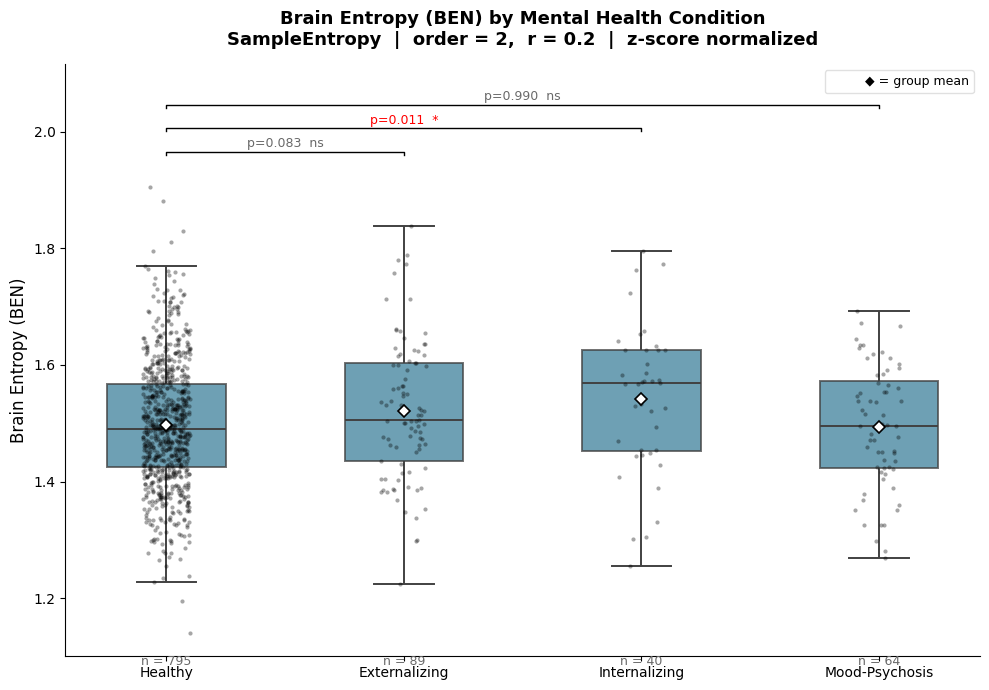


 Group Statistics: 
                  N    Mean     Std  Median     Min     Max
Condition                                                  
Externalizing    89  1.5204  0.1190  1.5056  1.2252  1.8389
Healthy         795  1.4972  0.1069  1.4908  1.1405  1.9054
Internalizing    40  1.5411  0.1271  1.5682  1.2548  1.7946
Mood-Psychosis   64  1.4932  0.1055  1.4961  1.2683  1.6919


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np
from scipy.stats import mannwhitneyu

# LOAD
labels = pd.read_csv("/content/MINI_label.csv")
ben    = pd.read_csv("/content/BEN_values_order2.csv")

labels.columns = labels.columns.str.strip()
df = pd.merge(labels, ben, on="User.code")

# ASSIGN CONDITION

def assign_condition(row):
    ext = row["externalizing_spectrum"]
    int_ = row["internalizing_spectrum"]
    moo = row["mood_psychosis_spectrum"]

    if ext == 0 and int_ == 0 and moo == 0:
        return "Healthy"
    elif moo == 1:
        return "Mood-Psychosis"
    elif ext == 1:
        return "Externalizing"
    else:
        return "Internalizing"

df["Condition"] = df.apply(assign_condition, axis=1)

print("Group counts:")
print(df["Condition"].value_counts())
print()

# PLOT SETUP
order   = ["Healthy", "Externalizing", "Internalizing", "Mood-Psychosis"]
palette = {
    "Healthy":          "#2E86AB",
    "Externalizing":    "#2E86AB",
    "Internalizing":    "#2E86AB",
    "Mood-Psychosis":   "#2E86AB",
}

fig, ax = plt.subplots(figsize=(10, 7))

# BOXPLOT
sns.boxplot(
    data     = df,
    x        = "Condition",
    y        = "BEN",
    order    = order,
    palette  = palette,
    width    = 0.5,
    linewidth= 1.4,
    fliersize= 0,          # hide default outlier dots — shown by stripplot
    ax       = ax,
    boxprops = dict(alpha=0.75),
)

# STRIPPLOT (individual dots)
sns.stripplot(
    data    = df,
    x       = "Condition",
    y       = "BEN",
    order   = order,
    color   = "black",
    size    = 3,
    alpha   = 0.35,
    jitter  = True,
    ax      = ax,
)

# MEAN MARKERS
for i, cond in enumerate(order):
    mean_val = df[df["Condition"] == cond]["BEN"].mean()
    ax.plot(i, mean_val, marker="D", color="white",
            markersize=6, markeredgecolor="black",
            markeredgewidth=1.2, zorder=5, label="_nolegend_")

# SIGNIFICANCE STARS (vs Healthy)
healthy_ben = df[df["Condition"] == "Healthy"]["BEN"]
y_top       = df["BEN"].max() + 0.03
gap         = 0.03

for i, cond in enumerate(order[1:], start=1):
    group_ben = df[df["Condition"] == cond]["BEN"]
    if len(group_ben) < 2:
        continue
    stat, p = mannwhitneyu(healthy_ben, group_ben, alternative="two-sided")

    # significance label
    if   p < 0.001: sig = "***"
    elif p < 0.01:  sig = "**"
    elif p < 0.05:  sig = "*"
    else:           sig = "ns"

    bar_y = y_top + gap
    # draw bracket line
    ax.plot([0, 0, i, i],
            [bar_y - 0.005, bar_y, bar_y, bar_y - 0.005],
            color="black", linewidth=1.0)
    # p-value text
    ax.text((0 + i) / 2, bar_y + 0.003,
            f"p={p:.3f}  {sig}",
            ha="center", va="bottom", fontsize=9,
            color="red" if p < 0.05 else "dimgray")
    gap += 0.04

# LABELS & STYLING
ax.set_title(
    "Brain Entropy (BEN) by Mental Health Condition\n"
    "SampleEntropy  |  order = 2,  r = 0.2  |  z-score normalized",
    fontsize=13, fontweight="bold", pad=14
)
ax.set_ylabel("Brain Entropy (BEN)", fontsize=12)
ax.set_xlabel("")
ax.set_ylim(df["BEN"].min() - 0.04, y_top + gap + 0.03)

# add sample-size annotation under each x-tick
for i, cond in enumerate(order):
    n = len(df[df["Condition"] == cond])
    ax.text(i, df["BEN"].min() - 0.055, f"n = {n}",
            ha="center", fontsize=9, color="dimgray")

# mean diamond legend
diamond_patch = mpatches.Patch(color="white", label="◆ = group mean",
                                linewidth=1.2)
ax.legend(handles=[diamond_patch], loc="upper right",
          fontsize=9, framealpha=0.6)

sns.despine()
plt.tight_layout()
plt.savefig("/content/BEN_boxplot_order2.png", dpi=150, bbox_inches="tight")
print("Saved → /content/BEN_boxplot_order2.png")
plt.show()

# PRINT STATS TABLE
print("\n Group Statistics: ")
stats = df.groupby("Condition")["BEN"].agg(
    N      = "count",
    Mean   = "mean",
    Std    = "std",
    Median = "median",
    Min    = "min",
    Max    = "max",
)
print(stats.round(4).to_string())

Total subjects       : 988
Features used        : BEN + 45 connectivity = 46 total
Age range            : 5.50 → 24.26 years
Healthy / Unhealthy  : 795 / 193

Model                    F1     F2     F3     F4     F5   Mean MAE      R²
--------------------------------------------------------------------------------
Ridge                3.70  3.54  2.95  3.48  3.13   3.359±0.28  0.111
ElasticNet           3.75  3.47  2.89  3.50  3.11   3.346±0.31  0.138
Random Forest        3.93  3.45  2.89  3.54  3.17   3.395±0.35  0.135
Gradient Boosting    3.83  3.28  2.97  3.37  3.16   3.322±0.28  0.150
SVR (RBF)            3.59  3.44  2.90  3.35  3.11   3.280±0.24  0.139

 Best model : SVR (RBF)  →  MAE = 3.280 years

BAG SUMMARY
Overall   : mean=0.0028  std=4.0814
Healthy   : mean=-0.0127  std=4.1519  n=795
Unhealthy : mean=0.0665  std=3.7868  n=193

t-test: t=-0.242, p=0.8091 → ns


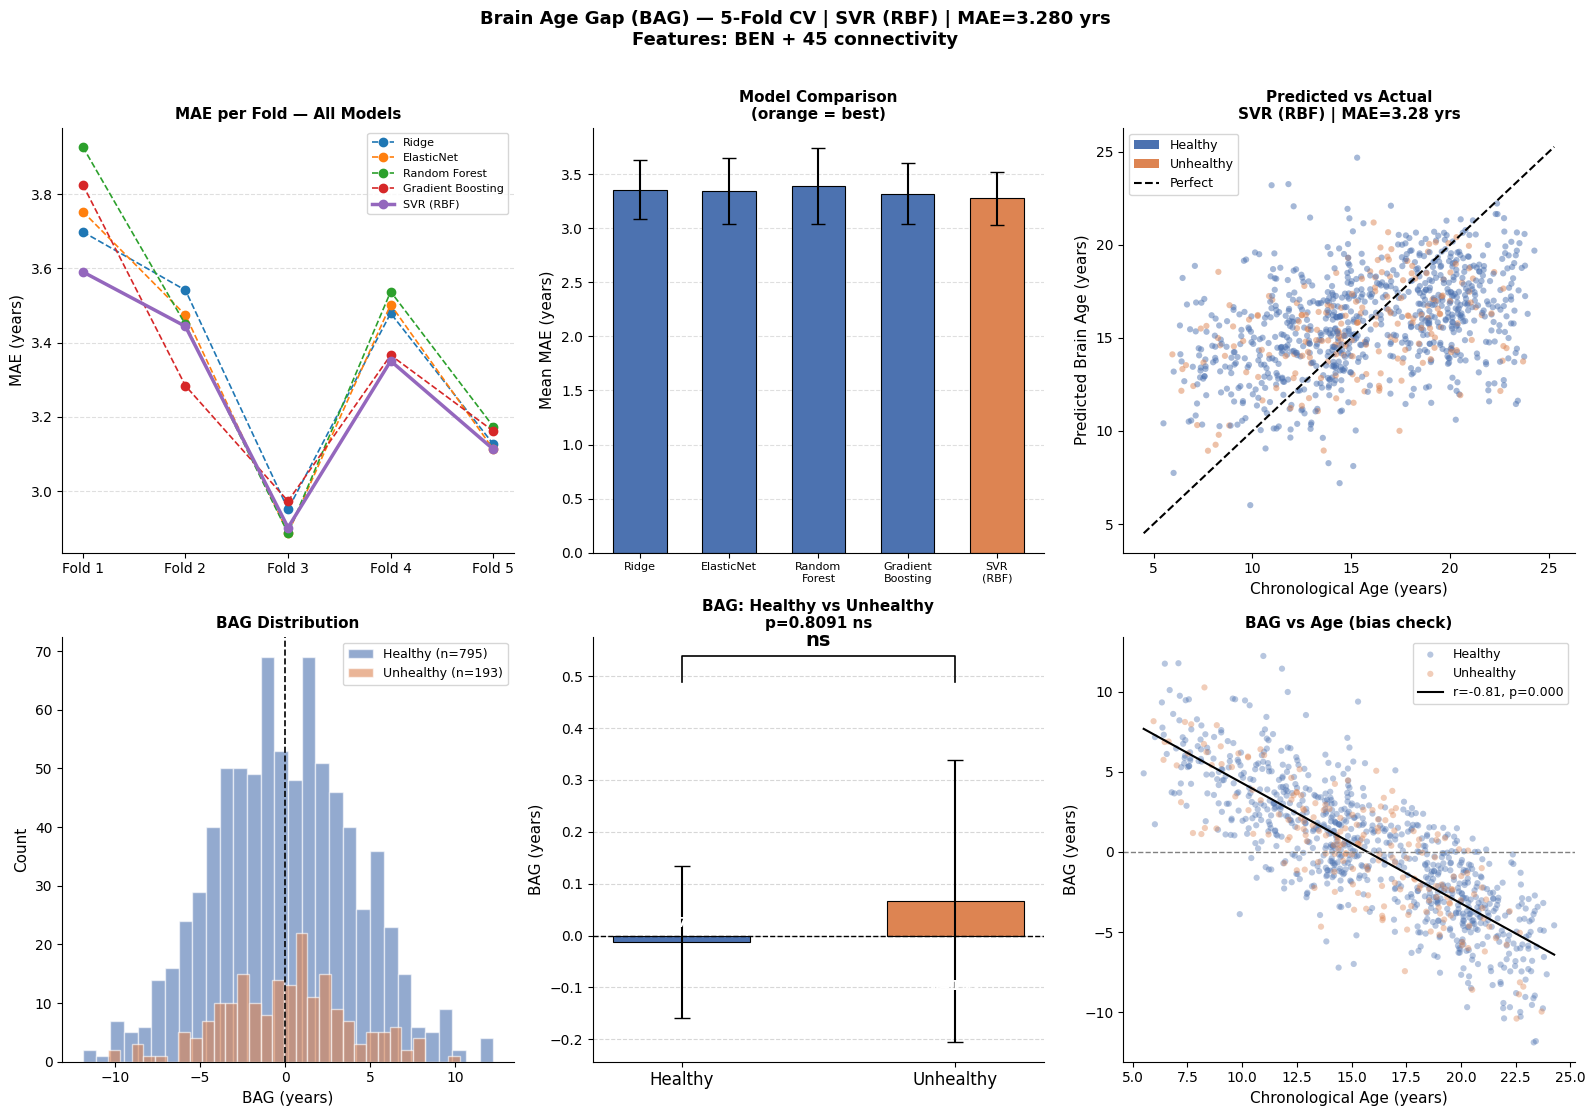


Saved → BAG_optimized_2_results.csv


In [22]:
# BRAIN AGE GAP (BAG) — BEN + 45 Connectivity Features
# 5-Fold CV | Multiple Models | BAG Minimized

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.linear_model import Ridge, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from matplotlib.patches import Patch


# STEP 1: LOAD & MERGE ALL
df_age   = pd.read_csv("/content/cveda_z_smith10.csv")
df_label = pd.read_csv("/content/MINI_label.csv")
df_ben   = pd.read_csv("/content/BEN_values_order2.csv")

df_label.columns = df_label.columns.str.strip()
df_age["User.code"]   = df_age["sub_id"].str.replace("sub-000","").str.lstrip("0").astype(str)
df_label["User.code"] = df_label["User.code"].astype(str).str.strip()
df_ben["User.code"]   = df_ben["User.code"].astype(str).str.strip()

# Connectivity feature columns
conn_cols = [c for c in df_age.columns
             if c not in ["sub_id","age","sex","site","mean_FD","User.code"]]

# Merge: BEN + connectivity + age + labels
df = df_ben.merge(df_age[["User.code","age","mean_FD"] + conn_cols],
                  on="User.code", how="inner")
df = df.merge(df_label[["User.code",
                          "externalizing_spectrum",
                          "internalizing_spectrum",
                          "mood_psychosis_spectrum"]],
              on="User.code", how="left")
df = df.dropna(subset=["BEN","age"]).reset_index(drop=True)

# Health label
df["group"] = np.where(
    (df["externalizing_spectrum"] == 0) &
    (df["internalizing_spectrum"]  == 0) &
    (df["mood_psychosis_spectrum"] == 0),
    "Healthy", "Unhealthy"
)

print(f"Total subjects       : {len(df)}")
print(f"Features used        : BEN + {len(conn_cols)} connectivity = {1+len(conn_cols)} total")
print(f"Age range            : {df['age'].min():.2f} → {df['age'].max():.2f} years")
print(f"Healthy / Unhealthy  : {(df['group']=='Healthy').sum()} / {(df['group']=='Unhealthy').sum()}")


# STEP 2: FEATURE MATRIX
# BEN + all 45 connectivity features
feature_cols = ["BEN"] + conn_cols
X = df[feature_cols].values
y = df["age"].values


# STEP 3: 5-FOLD CV — ALL MODELS
kf = KFold(n_splits=5, shuffle=True, random_state=42)

models = {
    "Ridge":             Ridge(alpha=1.0),
    "ElasticNet":        ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=5000),
    "Random Forest":     RandomForestRegressor(n_estimators=300,
                                               max_depth=6,
                                               random_state=42,
                                               n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=300,
                                                    max_depth=4,
                                                    learning_rate=0.05,
                                                    random_state=42),
    "SVR (RBF)":         SVR(kernel="rbf", C=10, gamma="scale"),
}

print("\n" + "="*80)
print(f"{'Model':<20} {'F1':>6} {'F2':>6} {'F3':>6} {'F4':>6} {'F5':>6}  {'Mean MAE':>9}  {'R²':>6}")
print("-"*80)

all_results = []
best_mae    = 999
best_preds  = None
best_name   = ""

scaler = StandardScaler()

for name, model in models.items():
    fold_maes  = []
    fold_preds = np.zeros(len(y))

    for train_idx, test_idx in kf.split(X):
        X_train = scaler.fit_transform(X[train_idx])
        X_test  = scaler.transform(X[test_idx])
        y_train, y_test = y[train_idx], y[test_idx]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        fold_preds[test_idx] = y_pred
        fold_maes.append(mean_absolute_error(y_test, y_pred))

    mean_mae = np.mean(fold_maes)
    std_mae  = np.std(fold_maes)
    r2       = r2_score(y, fold_preds)

    folds_str = "  ".join([f"{m:.2f}" for m in fold_maes])
    print(f"{name:<20} {folds_str}   {mean_mae:.3f}±{std_mae:.2f}  {r2:.3f}")

    all_results.append({"model": name, "fold_maes": fold_maes,
                        "mean_mae": mean_mae, "std_mae": std_mae,
                        "r2": r2, "preds": fold_preds.copy()})

    if mean_mae < best_mae:
        best_mae   = mean_mae
        best_preds = fold_preds.copy()
        best_name  = name

print(f"\n Best model : {best_name}  →  MAE = {best_mae:.3f} years")


# STEP 4: BAG COMPUTATION
df["predicted_age"] = best_preds
df["BAG"]           = df["predicted_age"] - df["age"]

print(f"\n{'='*50}")
print("BAG SUMMARY")
print(f"{'='*50}")
print(f"Overall   : mean={df['BAG'].mean():.4f}  std={df['BAG'].std():.4f}")
for grp in ["Healthy","Unhealthy"]:
    s = df[df["group"]==grp]["BAG"]
    print(f"{grp:<10}: mean={s.mean():.4f}  std={s.std():.4f}  n={len(s)}")

t, p = stats.ttest_ind(df[df["group"]=="Healthy"]["BAG"],
                        df[df["group"]=="Unhealthy"]["BAG"])
sig = "***" if p<0.001 else "**" if p<0.01 else "*" if p<0.05 else "ns"
print(f"\nt-test: t={t:.3f}, p={p:.4f} → {sig}")

# STEP 5: PLOTS
fig, axes = plt.subplots(2, 3, figsize=(16, 11))

# Plot 1: Per-fold MAE all models
ax = axes[0, 0]
fold_labels = [f"Fold {i+1}" for i in range(5)]
for res in all_results:
    lw  = 2.5 if res["model"] == best_name else 1.2
    ls  = "-"  if res["model"] == best_name else "--"
    ax.plot(fold_labels, res["fold_maes"],
            marker="o", label=res["model"],
            linewidth=lw, linestyle=ls)
ax.set_ylabel("MAE (years)", fontsize=11)
ax.set_title("MAE per Fold — All Models", fontsize=11, fontweight="bold")
ax.legend(fontsize=8)
ax.spines[["top","right"]].set_visible(False)
ax.yaxis.grid(True, linestyle="--", alpha=0.4)

# Plot 2: Mean MAE comparison
ax2 = axes[0, 1]
names_short = [r["model"].replace(" ","\n") for r in all_results]
mean_maes   = [r["mean_mae"] for r in all_results]
std_maes    = [r["std_mae"]  for r in all_results]
bar_cols    = ["#DD8452" if r["model"]==best_name else "#4C72B0"
               for r in all_results]

ax2.bar(range(len(all_results)), mean_maes, yerr=std_maes,
        color=bar_cols, edgecolor="black",
        capsize=5, width=0.6, linewidth=0.8)
ax2.set_xticks(range(len(all_results)))
ax2.set_xticklabels(names_short, fontsize=8)
ax2.set_ylabel("Mean MAE (years)", fontsize=11)
ax2.set_title("Model Comparison\n(orange = best)", fontsize=11, fontweight="bold")
ax2.spines[["top","right"]].set_visible(False)
ax2.yaxis.grid(True, linestyle="--", alpha=0.4)
ax2.set_axisbelow(True)

# Plot 3: Predicted vs Actual
ax3 = axes[0, 2]
c_map = ["#4C72B0" if g=="Healthy" else "#DD8452" for g in df["group"]]
ax3.scatter(df["age"], df["predicted_age"],
            c=c_map, alpha=0.5, s=20, edgecolors="none")
lims = [df["age"].min()-1, df["age"].max()+1]
ax3.plot(lims, lims, "k--", linewidth=1.5, label="Perfect")
ax3.set_xlabel("Chronological Age (years)", fontsize=11)
ax3.set_ylabel("Predicted Brain Age (years)", fontsize=11)
ax3.set_title(f"Predicted vs Actual\n{best_name} | MAE={best_mae:.2f} yrs",
              fontsize=11, fontweight="bold")
ax3.legend(handles=[Patch(facecolor="#4C72B0", label="Healthy"),
                    Patch(facecolor="#DD8452", label="Unhealthy"),
                    plt.Line2D([0],[0], color="k", linestyle="--", label="Perfect")], fontsize=9)
ax3.spines[["top","right"]].set_visible(False)

# Plot 4: BAG histogram
ax4 = axes[1, 0]
ax4.axvline(0, color="black", linestyle="--", linewidth=1.2)
for grp, col in [("Healthy","#4C72B0"),("Unhealthy","#DD8452")]:
    s = df[df["group"]==grp]["BAG"]
    ax4.hist(s, bins=30, alpha=0.6, color=col,
             edgecolor="white", label=f"{grp} (n={len(s)})")
ax4.set_xlabel("BAG (years)", fontsize=11)
ax4.set_ylabel("Count", fontsize=11)
ax4.set_title("BAG Distribution", fontsize=11, fontweight="bold")
ax4.legend(fontsize=9)
ax4.spines[["top","right"]].set_visible(False)

# Plot 5: BAG bar Healthy vs Unhealthy
ax5 = axes[1, 1]
means_b = [df[df["group"]==g]["BAG"].mean() for g in ["Healthy","Unhealthy"]]
sems_b  = [df[df["group"]==g]["BAG"].sem()  for g in ["Healthy","Unhealthy"]]
ns_b    = [len(df[df["group"]==g])           for g in ["Healthy","Unhealthy"]]

bars5 = ax5.bar([0,1], means_b, yerr=sems_b,
                color=["#4C72B0","#DD8452"],
                edgecolor="black", capsize=6,
                width=0.5, linewidth=0.8)
y_br = max(means_b[0]+sems_b[0], means_b[1]+sems_b[1]) + 0.15
ax5.plot([0,0,1,1],[y_br, y_br+0.05, y_br+0.05, y_br],
         color="black", linewidth=1.2)
ax5.text(0.5, y_br+0.07, sig,
         ha="center", fontsize=14, fontweight="bold")
for bar, n in zip(bars5, ns_b):
    ypos = bar.get_height() - 0.15 if bar.get_height() > 0 else bar.get_height() + 0.05
    ax5.text(bar.get_x()+bar.get_width()/2, ypos,
             f"n={n}", ha="center", va="top",
             fontsize=10, color="white", fontweight="bold")
ax5.axhline(0, color="black", linestyle="--", linewidth=1.0)
ax5.set_xticks([0,1])
ax5.set_xticklabels(["Healthy","Unhealthy"], fontsize=12)
ax5.set_ylabel("BAG (years)", fontsize=11)
ax5.set_title(f"BAG: Healthy vs Unhealthy\np={p:.4f} {sig}",
              fontsize=11, fontweight="bold")
ax5.spines[["top","right"]].set_visible(False)
ax5.yaxis.grid(True, linestyle="--", alpha=0.5)
ax5.set_axisbelow(True)

# Plot 6: BAG vs Age (bias check)
ax6 = axes[1, 2]
for grp, col in [("Healthy","#4C72B0"),("Unhealthy","#DD8452")]:
    s = df[df["group"]==grp]
    ax6.scatter(s["age"], s["BAG"],
                c=col, alpha=0.4, s=20,
                edgecolors="none", label=grp)
# Regression line to show age bias
m, b, r_val, p_val, _ = stats.linregress(df["age"], df["BAG"])
x_line = np.linspace(df["age"].min(), df["age"].max(), 100)
ax6.plot(x_line, m*x_line+b, "k-", linewidth=1.5,
         label=f"r={r_val:.2f}, p={p_val:.3f}")
ax6.axhline(0, color="gray", linestyle="--", linewidth=1.0)
ax6.set_xlabel("Chronological Age (years)", fontsize=11)
ax6.set_ylabel("BAG (years)", fontsize=11)
ax6.set_title("BAG vs Age (bias check)", fontsize=11, fontweight="bold")
ax6.legend(fontsize=9)
ax6.spines[["top","right"]].set_visible(False)

plt.suptitle(f"Brain Age Gap (BAG) — 5-Fold CV | {best_name} | MAE={best_mae:.3f} yrs\n"
             f"Features: BEN + {len(conn_cols)} connectivity",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("/content/BAG_optimized_2.png", dpi=150, bbox_inches="tight")
plt.show()

# Save
df[["User.code","age","predicted_age","BAG","BEN","group"]].to_csv(
    "/content/BAG_optimized_2_results.csv", index=False)
print("\nSaved → BAG_optimized_2_results.csv")

**Sample Entropy (order = 3, tolerance = 0.6) -> as per the paper**

In [7]:
# BEN CODE — z-score normalized, correct ROI count for order = 3

!pip install antropy pandas numpy tqdm joblib --quiet

import os
import zipfile
import numpy as np
import pandas as pd
from tqdm import tqdm
from antropy import sample_entropy
from joblib import Parallel, delayed
import multiprocessing

csv_path  = "/content/MINI_label.csv"
zip_path  = "/content/netts_files.zip"

df = pd.read_csv(csv_path)
df.columns = df.columns.str.strip()

extract_folder = "/content/netts_data"
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_folder)

data_folder = "/content/netts_data/Glasser_HCP"
print("Total files:", len(os.listdir(data_folder)))

# BEN FUNCTION — with z-score normalization (critical fix)
def compute_subject_ben(row):
    try:
        usercode = str(int(row["User.code"]))
        filename = f"sub-{usercode.zfill(12)}_000.netts"
        filepath = os.path.join(data_folder, filename)

        if not os.path.exists(filepath):
            return None

        ts = np.loadtxt(filepath)         # shape: (360, n_rois) — n_rois=164 or 155

        if ts.ndim == 1:
            ts = ts.reshape(-1, 1)

        roi_entropy = []

        for col in range(ts.shape[1]):
            signal = ts[:, col]
            signal = signal[~np.isnan(signal)]

            if len(signal) < 10:
                continue

            std = np.std(signal)
            if std < 1e-10:
                continue

            # CRITICAL FIX: z-score normalize before SampleEntropy
            # Without this, r = 0.2 * ~2700 = huge → all subjects get ~same SE
            signal = (signal - np.mean(signal)) / std

            try:
                # order=3 r=0.6 as per the paper
                e = sample_entropy(signal, order=3, tolerance=0.6)
                if np.isfinite(e):
                    roi_entropy.append(float(e))
            except:
                continue

        if len(roi_entropy) == 0:
            return None

        return [usercode, float(np.mean(roi_entropy))]

    except:
        return None

# PARALLEL PROCESSING
n_jobs = multiprocessing.cpu_count()
print(f"Using {n_jobs} CPU cores")

results = Parallel(n_jobs=n_jobs)(
    delayed(compute_subject_ben)(row)
    for _, row in tqdm(df.iterrows(), total=len(df))
)

results = [r for r in results if r is not None]

res = pd.DataFrame(results, columns=["User.code", "BEN"])

# Quick sanity check — BEN should vary meaningfully across subjects
print(f"\nTotal subjects processed: {len(res)}")
print(f"BEN range   : {res['BEN'].min():.4f} → {res['BEN'].max():.4f}")
print(f"BEN mean    : {res['BEN'].mean():.4f}")
print(f"BEN std     : {res['BEN'].std():.4f}")        # should be > 0.05 if working correctly
print(res.head(10))

res.to_csv("/content/BEN_values_order3.csv", index=False)
print("Saved BEN_values_order3.csv")

Total files: 1024
Using 2 CPU cores


100%|██████████| 8351/8351 [01:34<00:00, 88.79it/s] 



Total subjects processed: 988
BEN range   : 0.4209 → 0.8307
BEN mean    : 0.6183
BEN std     : 0.0648
  User.code       BEN
0  10155078  0.712079
1  10218000  0.597646
2  10225245  0.621869
3  10229783  0.611496
4  10382566  0.602230
5  10387970  0.653694
6  10450441  0.676718
7  10488996  0.706392
8  10574254  0.696565
9  10683468  0.598125
Saved BEN_values_order3.csv


Condition
Healthy      795
Unhealthy    193
Name: count, dtype: int64


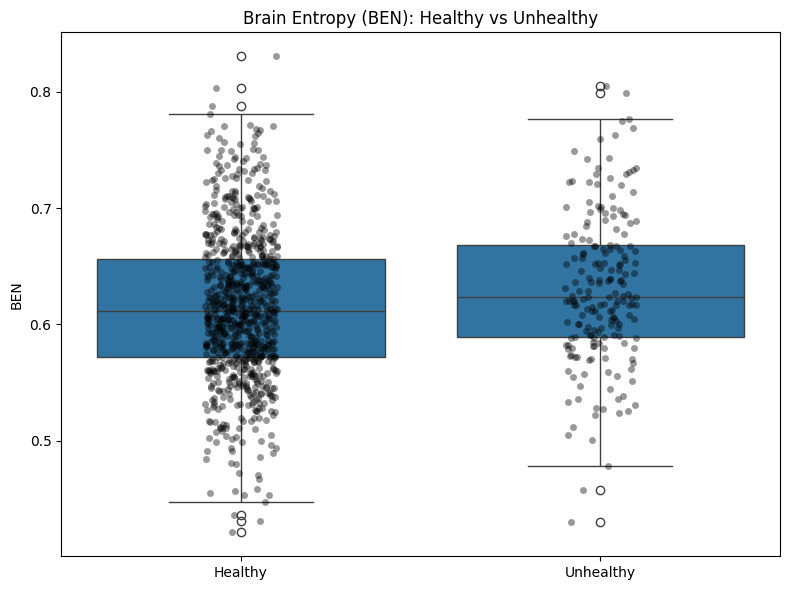

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load files
labels = pd.read_csv("/content/MINI_label.csv")
ben = pd.read_csv("/content/BEN_values_order3.csv")

labels.columns = labels.columns.str.strip()

# Merge
df = pd.merge(labels, ben, on="User.code")

# Healthy vs Unhealthy
df["Condition"] = df.apply(
    lambda row: "Healthy"
    if row["externalizing_spectrum"]==0 and
       row["internalizing_spectrum"]==0 and
       row["mood_psychosis_spectrum"]==0
    else "Unhealthy",
    axis=1
)

print(df["Condition"].value_counts())

# Plot
plt.figure(figsize=(8,6))

sns.boxplot(data=df, x="Condition", y="BEN")

sns.stripplot(data=df, x="Condition", y="BEN",
              color="black", alpha=0.4)

plt.title("Brain Entropy (BEN): Healthy vs Unhealthy")
plt.ylabel("BEN")
plt.xlabel("")
plt.tight_layout()
plt.show()

In [9]:
import pandas as pd

# LOAD FILES
labels = pd.read_csv("/content/MINI_label.csv")
ben = pd.read_csv("/content/BEN_values_order3.csv")

labels.columns = labels.columns.str.strip()


# MERGE ON User.code
df = pd.merge(labels, ben, on="User.code")
df["Condition"] = df.apply(
    lambda row: "Healthy"
    if row["externalizing_spectrum"] == 0 and
       row["internalizing_spectrum"] == 0 and
       row["mood_psychosis_spectrum"] == 0
    else "Unhealthy",
    axis=1
)

# CALCULATE MEANS
group_stats = df.groupby("Condition")["BEN"].agg(
    Count="count",
    Mean="mean",
    Std="std",
    Median="median",
    Min="min",
    Max="max"
)

print(group_stats)

# OUTPUT
healthy_mean = df[df["Condition"]=="Healthy"]["BEN"].mean()
unhealthy_mean = df[df["Condition"]=="Unhealthy"]["BEN"].mean()

print("\nMean BEN Values:")
print("Healthy   :", round(healthy_mean,4))
print("Unhealthy :", round(unhealthy_mean,4))
print("Difference:", round(unhealthy_mean - healthy_mean,4))

           Count      Mean       Std    Median       Min       Max
Condition                                                         
Healthy      795  0.615253  0.064364  0.611614  0.420906  0.830748
Unhealthy    193  0.630620  0.065241  0.623427  0.430288  0.804964

Mean BEN Values:
Healthy   : 0.6153
Unhealthy : 0.6306
Difference: 0.0154


In [10]:
from scipy.stats import mannwhitneyu

h = df[df["Condition"]=="Healthy"]["BEN"]
u = df[df["Condition"]=="Unhealthy"]["BEN"]

stat,p = mannwhitneyu(h,u,alternative="two-sided")

print("p =",p)

p = 0.0027734721957543814


Group counts:
Condition
Healthy           795
Externalizing      89
Mood-Psychosis     64
Internalizing      40
Name: count, dtype: int64



/tmp/ipykernel_13087/1800905072.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


Saved → /content/BEN_boxplot_order3.png


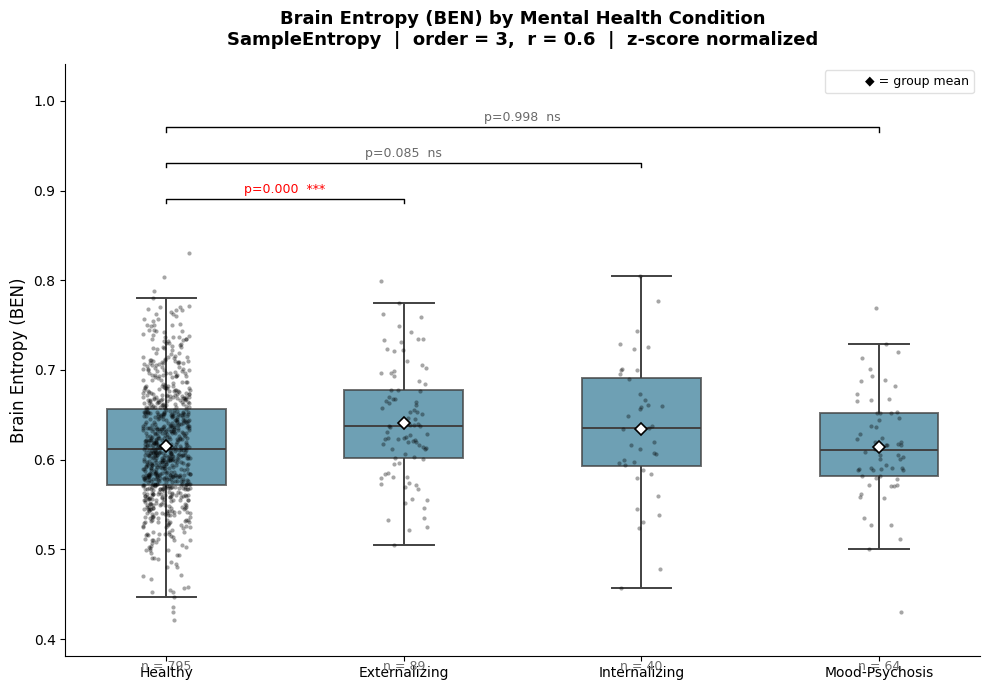


 Group Statistics: 
                  N    Mean     Std  Median     Min     Max
Condition                                                  
Externalizing    89  0.6411  0.0627  0.6376  0.5046  0.7989
Healthy         795  0.6153  0.0644  0.6116  0.4209  0.8307
Internalizing    40  0.6340  0.0767  0.6349  0.4574  0.8050
Mood-Psychosis   64  0.6139  0.0583  0.6103  0.4303  0.7689


In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np
from scipy.stats import mannwhitneyu

# LOAD
labels = pd.read_csv("/content/MINI_label.csv")
ben    = pd.read_csv("/content/BEN_values_order3.csv")

labels.columns = labels.columns.str.strip()
df = pd.merge(labels, ben, on="User.code")

# ASSIGN CONDITION

def assign_condition(row):
    ext = row["externalizing_spectrum"]
    int_ = row["internalizing_spectrum"]
    moo = row["mood_psychosis_spectrum"]

    if ext == 0 and int_ == 0 and moo == 0:
        return "Healthy"
    elif moo == 1:
        return "Mood-Psychosis"
    elif ext == 1:
        return "Externalizing"
    else:
        return "Internalizing"

df["Condition"] = df.apply(assign_condition, axis=1)

print("Group counts:")
print(df["Condition"].value_counts())
print()

# PLOT SETUP
order   = ["Healthy", "Externalizing", "Internalizing", "Mood-Psychosis"]
palette = {
    "Healthy":          "#2E86AB",
    "Externalizing":    "#2E86AB",
    "Internalizing":    "#2E86AB",
    "Mood-Psychosis":"#2E86AB",
}

fig, ax = plt.subplots(figsize=(10, 7))

# BOXPLOT
sns.boxplot(
    data     = df,
    x        = "Condition",
    y        = "BEN",
    order    = order,
    palette  = palette,
    width    = 0.5,
    linewidth= 1.4,
    fliersize= 0,          # hide default outlier dots — shown by stripplot
    ax       = ax,
    boxprops = dict(alpha=0.75),
)

# STRIPPLOT (individual dots)
sns.stripplot(
    data    = df,
    x       = "Condition",
    y       = "BEN",
    order   = order,
    color   = "black",
    size    = 3,
    alpha   = 0.35,
    jitter  = True,
    ax      = ax,
)

# MEAN MARKERS
for i, cond in enumerate(order):
    mean_val = df[df["Condition"] == cond]["BEN"].mean()
    ax.plot(i, mean_val, marker="D", color="white",
            markersize=6, markeredgecolor="black",
            markeredgewidth=1.2, zorder=5, label="_nolegend_")

# SIGNIFICANCE STARS (vs Healthy)
healthy_ben = df[df["Condition"] == "Healthy"]["BEN"]
y_top       = df["BEN"].max() + 0.03
gap         = 0.03

for i, cond in enumerate(order[1:], start=1):
    group_ben = df[df["Condition"] == cond]["BEN"]
    if len(group_ben) < 2:
        continue
    stat, p = mannwhitneyu(healthy_ben, group_ben, alternative="two-sided")

    # significance label
    if   p < 0.001: sig = "***"
    elif p < 0.01:  sig = "**"
    elif p < 0.05:  sig = "*"
    else:           sig = "ns"

    bar_y = y_top + gap
    # draw bracket line
    ax.plot([0, 0, i, i],
            [bar_y - 0.005, bar_y, bar_y, bar_y - 0.005],
            color="black", linewidth=1.0)
    # p-value text
    ax.text((0 + i) / 2, bar_y + 0.003,
            f"p={p:.3f}  {sig}",
            ha="center", va="bottom", fontsize=9,
            color="red" if p < 0.05 else "dimgray")
    gap += 0.04

# LABELS & STYLING
ax.set_title(
    "Brain Entropy (BEN) by Mental Health Condition\n"
    "SampleEntropy  |  order = 3,  r = 0.6  |  z-score normalized",
    fontsize=13, fontweight="bold", pad=14
)
ax.set_ylabel("Brain Entropy (BEN)", fontsize=12)
ax.set_xlabel("")
ax.set_ylim(df["BEN"].min() - 0.04, y_top + gap + 0.03)

# add sample-size annotation under each x-tick
for i, cond in enumerate(order):
    n = len(df[df["Condition"] == cond])
    ax.text(i, df["BEN"].min() - 0.055, f"n = {n}",
            ha="center", fontsize=9, color="dimgray")

# mean diamond legend
diamond_patch = mpatches.Patch(color="white", label="◆ = group mean",
                                linewidth=1.2)
ax.legend(handles=[diamond_patch], loc="upper right",
          fontsize=9, framealpha=0.6)

sns.despine()
plt.tight_layout()
plt.savefig("/content/BEN_boxplot_order3.png", dpi=150, bbox_inches="tight")
print("Saved → /content/BEN_boxplot_order3.png")
plt.show()

# PRINT STATS TABLE
print("\n Group Statistics: ")
stats = df.groupby("Condition")["BEN"].agg(
    N      = "count",
    Mean   = "mean",
    Std    = "std",
    Median = "median",
    Min    = "min",
    Max    = "max",
)
print(stats.round(4).to_string())

Total subjects       : 988
Features used        : BEN + 45 connectivity = 46 total
Age range            : 5.50 → 24.26 years
Healthy / Unhealthy  : 795 / 193

Model                    F1     F2     F3     F4     F5   Mean MAE      R²
--------------------------------------------------------------------------------
Ridge                3.70  3.53  2.93  3.45  3.08   3.339±0.29  0.120
ElasticNet           3.75  3.46  2.88  3.48  3.07   3.329±0.31  0.145
Random Forest        3.92  3.44  2.88  3.53  3.14   3.384±0.35  0.138
Gradient Boosting    3.90  3.35  2.88  3.42  3.19   3.348±0.33  0.137
SVR (RBF)            3.61  3.41  2.88  3.32  3.09   3.263±0.26  0.148

 Best model : SVR (RBF)  →  MAE = 3.263 years

BAG SUMMARY
Overall   : mean=0.0094  std=4.0608
Healthy   : mean=-0.0214  std=4.1337  n=795
Unhealthy : mean=0.1365  std=3.7531  n=193

t-test: t=-0.484, p=0.6283 → ns


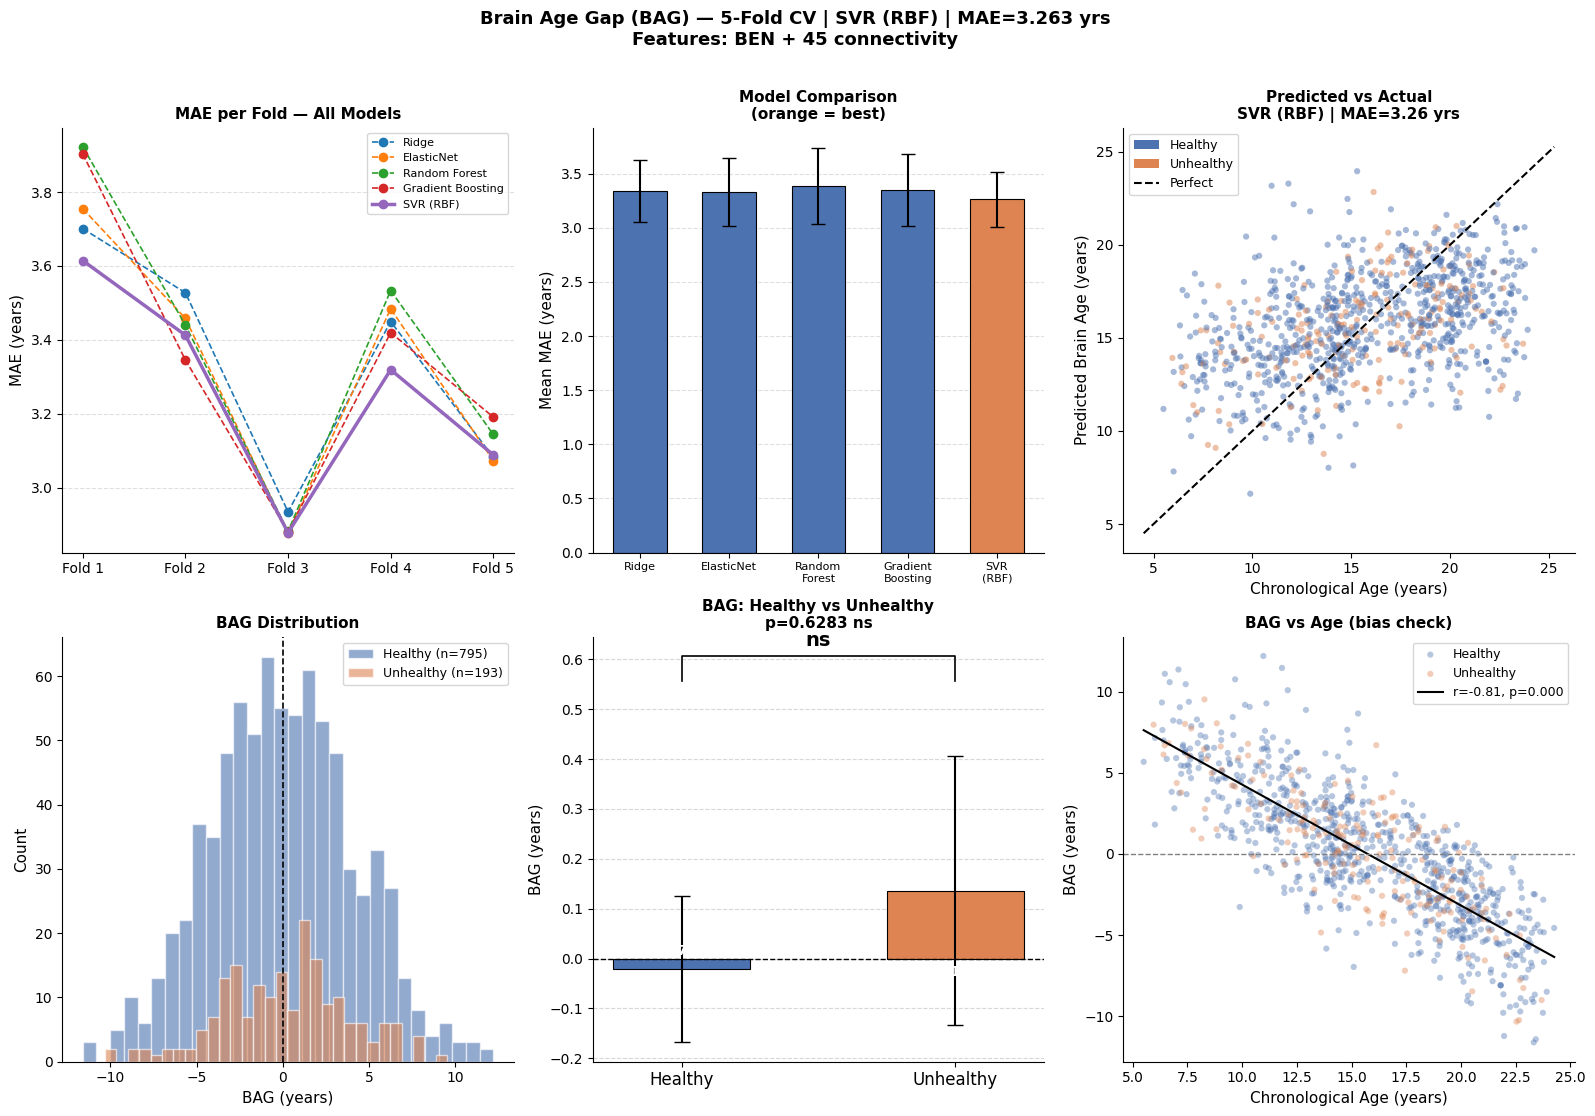


Saved → BAG_optimized_3_results.csv


In [23]:
# BRAIN AGE GAP (BAG) — BEN + 45 Connectivity Features
# 5-Fold CV | Multiple Models | BAG Minimized

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.linear_model import Ridge, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from matplotlib.patches import Patch


# STEP 1: LOAD & MERGE ALL
df_age   = pd.read_csv("/content/cveda_z_smith10.csv")
df_label = pd.read_csv("/content/MINI_label.csv")
df_ben   = pd.read_csv("/content/BEN_values_order3.csv")

df_label.columns = df_label.columns.str.strip()
df_age["User.code"]   = df_age["sub_id"].str.replace("sub-000","").str.lstrip("0").astype(str)
df_label["User.code"] = df_label["User.code"].astype(str).str.strip()
df_ben["User.code"]   = df_ben["User.code"].astype(str).str.strip()

# Connectivity feature columns
conn_cols = [c for c in df_age.columns
             if c not in ["sub_id","age","sex","site","mean_FD","User.code"]]

# Merge: BEN + connectivity + age + labels
df = df_ben.merge(df_age[["User.code","age","mean_FD"] + conn_cols],
                  on="User.code", how="inner")
df = df.merge(df_label[["User.code",
                          "externalizing_spectrum",
                          "internalizing_spectrum",
                          "mood_psychosis_spectrum"]],
              on="User.code", how="left")
df = df.dropna(subset=["BEN","age"]).reset_index(drop=True)

# Health label
df["group"] = np.where(
    (df["externalizing_spectrum"] == 0) &
    (df["internalizing_spectrum"]  == 0) &
    (df["mood_psychosis_spectrum"] == 0),
    "Healthy", "Unhealthy"
)

print(f"Total subjects       : {len(df)}")
print(f"Features used        : BEN + {len(conn_cols)} connectivity = {1+len(conn_cols)} total")
print(f"Age range            : {df['age'].min():.2f} → {df['age'].max():.2f} years")
print(f"Healthy / Unhealthy  : {(df['group']=='Healthy').sum()} / {(df['group']=='Unhealthy').sum()}")


# STEP 2: FEATURE MATRIX
# BEN + all 45 connectivity features
feature_cols = ["BEN"] + conn_cols
X = df[feature_cols].values
y = df["age"].values


# STEP 3: 5-FOLD CV — ALL MODELS
kf = KFold(n_splits=5, shuffle=True, random_state=42)

models = {
    "Ridge":             Ridge(alpha=1.0),
    "ElasticNet":        ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=5000),
    "Random Forest":     RandomForestRegressor(n_estimators=300,
                                               max_depth=6,
                                               random_state=42,
                                               n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=300,
                                                    max_depth=4,
                                                    learning_rate=0.05,
                                                    random_state=42),
    "SVR (RBF)":         SVR(kernel="rbf", C=10, gamma="scale"),
}

print("\n" + "="*80)
print(f"{'Model':<20} {'F1':>6} {'F2':>6} {'F3':>6} {'F4':>6} {'F5':>6}  {'Mean MAE':>9}  {'R²':>6}")
print("-"*80)

all_results = []
best_mae    = 999
best_preds  = None
best_name   = ""

scaler = StandardScaler()

for name, model in models.items():
    fold_maes  = []
    fold_preds = np.zeros(len(y))

    for train_idx, test_idx in kf.split(X):
        X_train = scaler.fit_transform(X[train_idx])
        X_test  = scaler.transform(X[test_idx])
        y_train, y_test = y[train_idx], y[test_idx]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        fold_preds[test_idx] = y_pred
        fold_maes.append(mean_absolute_error(y_test, y_pred))

    mean_mae = np.mean(fold_maes)
    std_mae  = np.std(fold_maes)
    r2       = r2_score(y, fold_preds)

    folds_str = "  ".join([f"{m:.2f}" for m in fold_maes])
    print(f"{name:<20} {folds_str}   {mean_mae:.3f}±{std_mae:.2f}  {r2:.3f}")

    all_results.append({"model": name, "fold_maes": fold_maes,
                        "mean_mae": mean_mae, "std_mae": std_mae,
                        "r2": r2, "preds": fold_preds.copy()})

    if mean_mae < best_mae:
        best_mae   = mean_mae
        best_preds = fold_preds.copy()
        best_name  = name

print(f"\n Best model : {best_name}  →  MAE = {best_mae:.3f} years")


# STEP 4: BAG COMPUTATION
df["predicted_age"] = best_preds
df["BAG"]           = df["predicted_age"] - df["age"]

print(f"\n{'='*50}")
print("BAG SUMMARY")
print(f"{'='*50}")
print(f"Overall   : mean={df['BAG'].mean():.4f}  std={df['BAG'].std():.4f}")
for grp in ["Healthy","Unhealthy"]:
    s = df[df["group"]==grp]["BAG"]
    print(f"{grp:<10}: mean={s.mean():.4f}  std={s.std():.4f}  n={len(s)}")

t, p = stats.ttest_ind(df[df["group"]=="Healthy"]["BAG"],
                        df[df["group"]=="Unhealthy"]["BAG"])
sig = "***" if p<0.001 else "**" if p<0.01 else "*" if p<0.05 else "ns"
print(f"\nt-test: t={t:.3f}, p={p:.4f} → {sig}")

# STEP 5: PLOTS
fig, axes = plt.subplots(2, 3, figsize=(16, 11))

# Plot 1: Per-fold MAE all models
ax = axes[0, 0]
fold_labels = [f"Fold {i+1}" for i in range(5)]
for res in all_results:
    lw  = 2.5 if res["model"] == best_name else 1.2
    ls  = "-"  if res["model"] == best_name else "--"
    ax.plot(fold_labels, res["fold_maes"],
            marker="o", label=res["model"],
            linewidth=lw, linestyle=ls)
ax.set_ylabel("MAE (years)", fontsize=11)
ax.set_title("MAE per Fold — All Models", fontsize=11, fontweight="bold")
ax.legend(fontsize=8)
ax.spines[["top","right"]].set_visible(False)
ax.yaxis.grid(True, linestyle="--", alpha=0.4)

# Plot 2: Mean MAE comparison
ax2 = axes[0, 1]
names_short = [r["model"].replace(" ","\n") for r in all_results]
mean_maes   = [r["mean_mae"] for r in all_results]
std_maes    = [r["std_mae"]  for r in all_results]
bar_cols    = ["#DD8452" if r["model"]==best_name else "#4C72B0"
               for r in all_results]

ax2.bar(range(len(all_results)), mean_maes, yerr=std_maes,
        color=bar_cols, edgecolor="black",
        capsize=5, width=0.6, linewidth=0.8)
ax2.set_xticks(range(len(all_results)))
ax2.set_xticklabels(names_short, fontsize=8)
ax2.set_ylabel("Mean MAE (years)", fontsize=11)
ax2.set_title("Model Comparison\n(orange = best)", fontsize=11, fontweight="bold")
ax2.spines[["top","right"]].set_visible(False)
ax2.yaxis.grid(True, linestyle="--", alpha=0.4)
ax2.set_axisbelow(True)

# Plot 3: Predicted vs Actual
ax3 = axes[0, 2]
c_map = ["#4C72B0" if g=="Healthy" else "#DD8452" for g in df["group"]]
ax3.scatter(df["age"], df["predicted_age"],
            c=c_map, alpha=0.5, s=20, edgecolors="none")
lims = [df["age"].min()-1, df["age"].max()+1]
ax3.plot(lims, lims, "k--", linewidth=1.5, label="Perfect")
ax3.set_xlabel("Chronological Age (years)", fontsize=11)
ax3.set_ylabel("Predicted Brain Age (years)", fontsize=11)
ax3.set_title(f"Predicted vs Actual\n{best_name} | MAE={best_mae:.2f} yrs",
              fontsize=11, fontweight="bold")
ax3.legend(handles=[Patch(facecolor="#4C72B0", label="Healthy"),
                    Patch(facecolor="#DD8452", label="Unhealthy"),
                    plt.Line2D([0],[0], color="k", linestyle="--", label="Perfect")], fontsize=9)
ax3.spines[["top","right"]].set_visible(False)

# Plot 4: BAG histogram
ax4 = axes[1, 0]
ax4.axvline(0, color="black", linestyle="--", linewidth=1.2)
for grp, col in [("Healthy","#4C72B0"),("Unhealthy","#DD8452")]:
    s = df[df["group"]==grp]["BAG"]
    ax4.hist(s, bins=30, alpha=0.6, color=col,
             edgecolor="white", label=f"{grp} (n={len(s)})")
ax4.set_xlabel("BAG (years)", fontsize=11)
ax4.set_ylabel("Count", fontsize=11)
ax4.set_title("BAG Distribution", fontsize=11, fontweight="bold")
ax4.legend(fontsize=9)
ax4.spines[["top","right"]].set_visible(False)

# Plot 5: BAG bar Healthy vs Unhealthy
ax5 = axes[1, 1]
means_b = [df[df["group"]==g]["BAG"].mean() for g in ["Healthy","Unhealthy"]]
sems_b  = [df[df["group"]==g]["BAG"].sem()  for g in ["Healthy","Unhealthy"]]
ns_b    = [len(df[df["group"]==g])           for g in ["Healthy","Unhealthy"]]

bars5 = ax5.bar([0,1], means_b, yerr=sems_b,
                color=["#4C72B0","#DD8452"],
                edgecolor="black", capsize=6,
                width=0.5, linewidth=0.8)
y_br = max(means_b[0]+sems_b[0], means_b[1]+sems_b[1]) + 0.15
ax5.plot([0,0,1,1],[y_br, y_br+0.05, y_br+0.05, y_br],
         color="black", linewidth=1.2)
ax5.text(0.5, y_br+0.07, sig,
         ha="center", fontsize=14, fontweight="bold")
for bar, n in zip(bars5, ns_b):
    ypos = bar.get_height() - 0.15 if bar.get_height() > 0 else bar.get_height() + 0.05
    ax5.text(bar.get_x()+bar.get_width()/2, ypos,
             f"n={n}", ha="center", va="top",
             fontsize=10, color="white", fontweight="bold")
ax5.axhline(0, color="black", linestyle="--", linewidth=1.0)
ax5.set_xticks([0,1])
ax5.set_xticklabels(["Healthy","Unhealthy"], fontsize=12)
ax5.set_ylabel("BAG (years)", fontsize=11)
ax5.set_title(f"BAG: Healthy vs Unhealthy\np={p:.4f} {sig}",
              fontsize=11, fontweight="bold")
ax5.spines[["top","right"]].set_visible(False)
ax5.yaxis.grid(True, linestyle="--", alpha=0.5)
ax5.set_axisbelow(True)

# Plot 6: BAG vs Age (bias check)
ax6 = axes[1, 2]
for grp, col in [("Healthy","#4C72B0"),("Unhealthy","#DD8452")]:
    s = df[df["group"]==grp]
    ax6.scatter(s["age"], s["BAG"],
                c=col, alpha=0.4, s=20,
                edgecolors="none", label=grp)
# Regression line to show age bias
m, b, r_val, p_val, _ = stats.linregress(df["age"], df["BAG"])
x_line = np.linspace(df["age"].min(), df["age"].max(), 100)
ax6.plot(x_line, m*x_line+b, "k-", linewidth=1.5,
         label=f"r={r_val:.2f}, p={p_val:.3f}")
ax6.axhline(0, color="gray", linestyle="--", linewidth=1.0)
ax6.set_xlabel("Chronological Age (years)", fontsize=11)
ax6.set_ylabel("BAG (years)", fontsize=11)
ax6.set_title("BAG vs Age (bias check)", fontsize=11, fontweight="bold")
ax6.legend(fontsize=9)
ax6.spines[["top","right"]].set_visible(False)

plt.suptitle(f"Brain Age Gap (BAG) — 5-Fold CV | {best_name} | MAE={best_mae:.3f} yrs\n"
             f"Features: BEN + {len(conn_cols)} connectivity",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("/content/BAG_optimized_3.png", dpi=150, bbox_inches="tight")
plt.show()

# Save
df[["User.code","age","predicted_age","BAG","BEN","group"]].to_csv(
    "/content/BAG_optimized_3_results.csv", index=False)
print("\nSaved → BAG_optimized_3_results.csv")